# Contexto
Una empresa quiere entender cómo su inversión publicitaria afecta sus ventas. Cuentan con datos de 200 observaciones con las siguientes variables:

| Variable | Descripción |
| :--- | :---: | 
| TV | Presupuesto en TV (miles de dólares) |
| Radio | Presupuesto en Radio (miles de dólares) | 
| Newspaper | Presupuesto en Periódico (miles de dólares) | 
| Sales | Ventas (miles de unidades)) |

Objetivo de la actividad: Construir un modelo de regresión lineal simple para predecir ventas usando la inversión en TV.

# Parte 1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats


df = pd.read_csv('https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv')

df.drop(columns=['Unnamed: 0'], inplace=True)

In [2]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [3]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


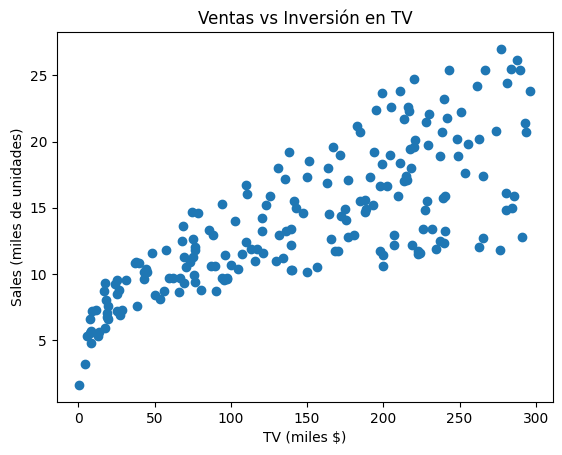

In [4]:

plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.title('Ventas vs Inversión en TV')
plt.show()


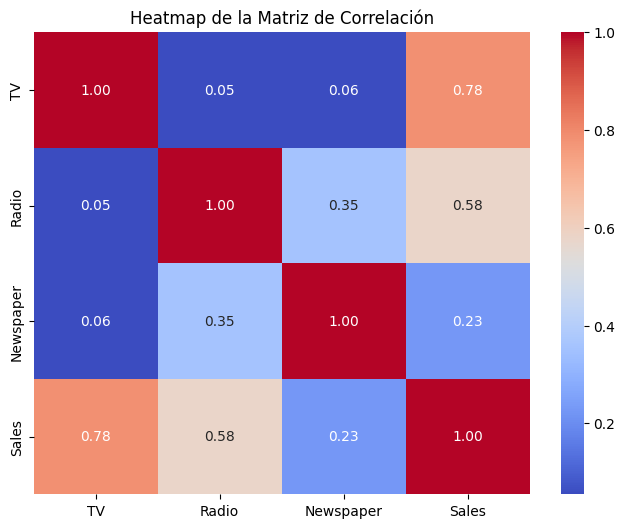

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de la Matriz de Correlación')
plt.show()

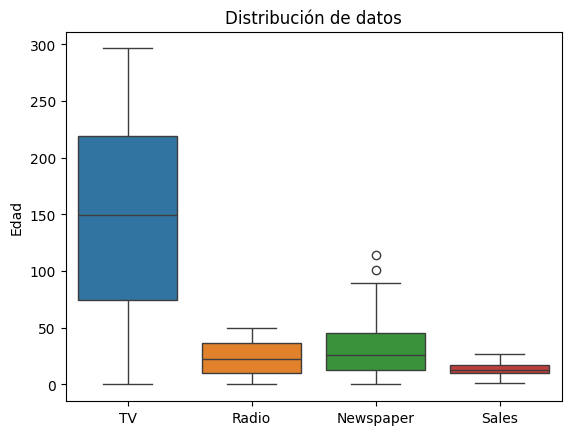

In [6]:
sns.boxplot(data=df)
plt.title('Distribución de datos')
plt.ylabel('Edad')
plt.show()

Distribución de variables:
* ¿Cuál es el rango de TV? ¿Y el de Sales? ¿Hay outliers?

*El rango de TV es 295.7, mientras que el rango de Sales es de 25.4. Existen valores atípicos en los datos de Newspaper, con valores cercanos a 114. *

* Correlación TV-Sales: ¿Es positiva o negativa? ¿Qué tan fuerte es?

*Se muestra una correlación positiva aceptable entre TV y Sales con un valor aproximado de 0.78. Es la más alta dentro del dataset*

*  Patrón en el scatter plot: ¿La relación parece lineal? ¿Hay puntos muy alejados del patrón general?

*La relación entre TV y sales parece presentar un comportamiento logaritmico, debido a la curva formada en los primeros miles de TV. A medida que se incrementa el valor de TV, podemos observar que se genera una mayor dispersión de los datos, comparado con los primeros valores.*



# Parte 2: Modelado
## 2A. Implementación desde cero con numpy


In [7]:
 # Extraer X y Y
X = df['TV'].values
Y = df['Sales'].values

# Calcular medias
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Calcular beta_1
numerator = np.sum((X - X_mean) * (Y - Y_mean))
denominator = np.sum((X - X_mean)**2)
beta_1 = numerator / denominator

# Calcular beta_0
beta_0 = Y_mean - beta_1 * X_mean

print(f'beta_0 = {beta_0:.3f}')
print(f'beta_1 = {beta_1:.3f}')

beta_0 = 7.033
beta_1 = 0.048


## 2B. Implementación con scikit-learn 

In [8]:
# Preparar datos (scikit-learn necesita X en formato 2D)
X = df[['TV']]
y = df['Sales']

# Crear y ajustar modelo
model = LinearRegression()
model.fit(X, y)

# Ver coeficientes
print(f'Intercepto: {model.intercept_:.3f}')
print(f'Pendiente: {model.coef_[0]:.3f}')

# Hacer predicciones
y_pred = model.predict(X)

Intercepto: 7.033
Pendiente: 0.048


## 2C. Calcular métricas

In [9]:
# MSE y RMSE
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

# R cuadrado
r2 = r2_score(y, y_pred)

print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

MSE: 10.513
RMSE: 3.242
R²: 0.612


# Parte 3: Visualización 


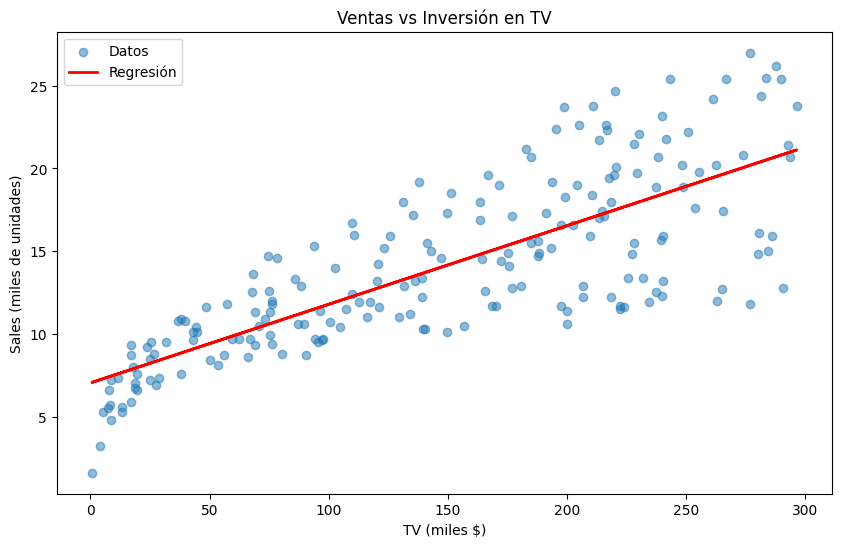

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Datos')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regresión')
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.legend()
plt.title('Ventas vs Inversión en TV')
plt.show()

## 3.2. Gráfico de residuos


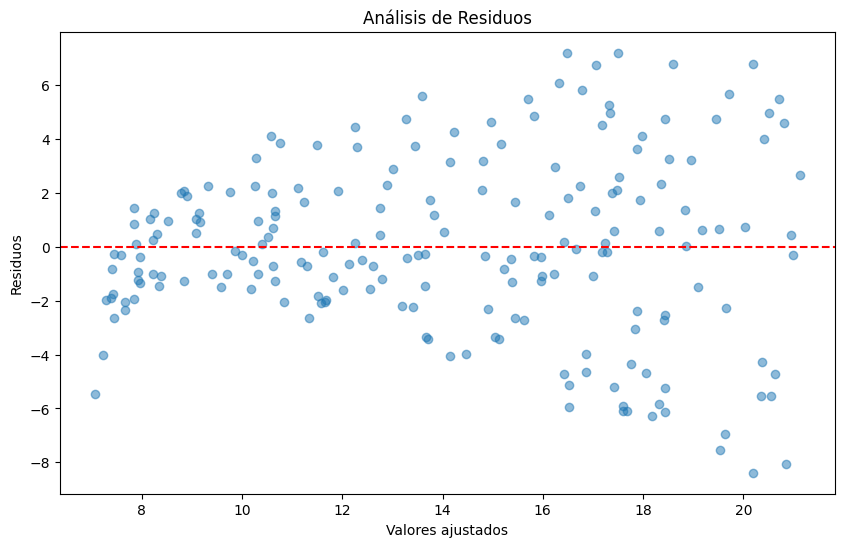

In [11]:
# Calcular residuos
residuals = y - y_pred

# Gráfico de residuos vs predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.show()

No se encuentra un patrón tan aleatorio, parece ser incluso que los residuos se comportan de igual forma que los datos originales. Se genera una forma de embudo que crece respecto al incremento de los valores ajustados. Además, como se nota en los datos originales, se identifican patrones curvos.

Además, los residuos no se encuentran cercanos a 0.

## 3.3. Q-Q Plot


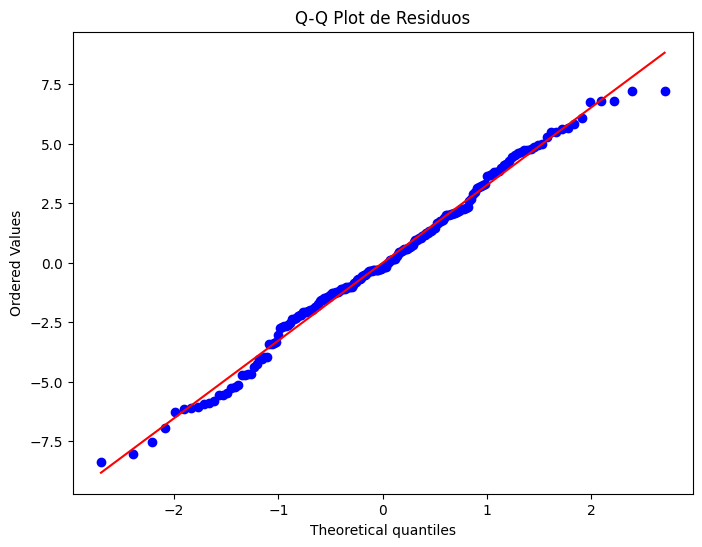

In [12]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

# Parte 4: Interpretación

Los resultados esperados del modelo son:

Sales= 7.03 + 0.048 × TV

Responde las siguientes preguntas:

1. ¿Qué significa β₀ = 7.03? (Pista: ¿cuántas ventas esperarías con $0 de inversión en TV?)

   *Indica que al no invertir se esperan ventas de 7.03 miles de unidades, pero debido a otras variables no consideradas (factores no considerados) o por la inercia de la marca.*
3. ¿Qué significa β₁ = 0.048?

   *Si se incrementa la inversión de TV mil dolares, se espera en promedio un aumento de ventas de 0.048 miles de unidades*
4. Si inviertes 100 mil dólares más en TV, ¿cuántas ventas adicionales esperas?

   *Al invertir 100 mil doláres en TV se esperan en promedio 4.8 miles de unidades de ventas adicionales.*
5. R² = 0.61. ¿Es bueno o malo? (Pista: ¿qué porcentaje de la variabilidad en ventas explica el modelo? ¿Qué porcentaje queda sin explicar?)

   *El modelo explica el 61% de la variabilidad observada en las ventas. Podemos considerar que en el contexto del planteamiento, el englobar el comportamiento en una sola variable son más del 60% es significativo.*
6. ¿Recomendarías invertir más en TV basándote solamente en este análisis?

   *Si, el coeficiente de betha 1 nos indica que hay una recomendación positiva para invertir en publicidad en TV y aumentar las ventas. El detalle es poder analizar más variables que influyen en la ganancia, y no solo en el volumen de las ventas.*